In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch

import ml_tools as mlt
import sim_ranking as sr
import spatial_hazard as sh

In [2]:
results_dir = Path("/Users/claudy/dev/work/data/sim_ranking/results/ml/0418_1401_cWeights_30_100_weighted")
db_ffp = Path("/Users/claudy/dev/work/data/sim_ranking/emp_realisations/perturbed_0313_100r/gm_db_emp.sqlite")
hp_config_ffp = Path("/Users/claudy/dev/work/code/sim_ranking/sim_ranking/ml_models/sc_prob_config.yaml")
corr_dir = Path("/Users/claudy/dev/work/data/sim_ranking/emp_realisations/event_loth_baker_correlations")

seed = 50

In [3]:
run_config = sr.ml.sc_prob.RunParamsConfig(
    30,
    100,
    sr.constants.IM_SETS["pSA"],
    sr.constants.IM_WEIGTHS_SETS["pSA"],
    True,
    True,
    0.5,
    2.0,
    sr.ml.sc_prob.SampleWeighting.CUSTOM_MODEL,
    False,
    "cpu",
    results_dir=None,
)

hp_config = sr.ml.sc_prob.HyperParamsConfig.from_yaml(hp_config_ffp, 100)
weight_model = torch.load(results_dir / "weight_model.pt", map_location=torch.device('cpu'))

db = sr.db.DB(db_ffp)

In [4]:
events = db.get_avail_events(data_source="emp")
print(f"Number of events: {len(events)}")

# Get all relevant sites across all events
all_sites = db.get_avail_sites()

### Data setup
# Get the sites per event
event_sites = db.get_event_sites()

# Split into training and validation
if seed is not None:
    print(f"Using numpy random seed: {seed}")
    np.random.seed(seed)
val_int_sites = np.random.choice(all_sites, 100, replace=False)
train_sites = np.setdiff1d(all_sites, val_int_sites)

val_events = np.random.choice(events, 75, replace=False)
train_events = np.setdiff1d(events, val_events)

train_dataset, val_dataset, scalar_features, data_metadata = sr.ml.sc_prob.data_prep(
    event_sites,
    train_events,
    val_events,
    train_sites,
    val_int_sites,
    events,
    run_config,
    hp_config,
    db,
    corr_dir=corr_dir,
)

Number of events: 258
Using numpy random seed: 50
Computing distance matrix
Pre-processing site & event features
Computing scalar features
Creating site combinations
Creating datasets


Processing events: 100%|██████████| 75/75 [00:02<00:00, 26.08it/s]

Number of training samples (scenarios): 3204
Number of validation samples (scenarios) : 582


In [5]:
data_loader = sr.ml.prob.CustomTabularDataLoader(train_dataset, batch_size=128, shuffle=False, shuffle_rels=False)

weight_cols = [f"{cur_pSA}_weight" for cur_pSA in sr.constants.PSA_KEYS]

results = []

for i, (
    batch_ind,
    rel_shuffle_ind,
    sc_ids,
    sc_im_misfit_score,
    record_scenario_ids,
    site_int_norm_sim_ims,
    site_obs_norm_sim_ims,
    site_obs_norm_obs_ims,
    site_int_sim_ims,
    site_obs_sim_ims,
    site_obs_obs_ims,
    scalar_features,
    im_misfit_score,
    im_site_corrs,
) in enumerate(data_loader):
    (
        events,
        record_events,
        site_int,
        record_site_int,
        site_obs,
        record_site_obs,
        rels,
        residual,
        record_residual,
        n_sites_scenario,
    ) = train_dataset.get_metadata(batch_ind, rel_shuffle_ind)
    
    # Scenario mask
    # scenario_mask = sr.ml.sc_prob.get_scenario_mask(record_scenario_ids, sc_ids)
    # scenario_mask = scenario_mask.to(run_config.device, torch.float32)
    
    w_pred = weight_model(scalar_features.to(torch.float32))
    
    cur_result = pd.DataFrame(columns=["event", "site_int", "site_obs"], data={"event": record_events, "site_int": record_site_int, "site_obs": record_site_obs})
    cur_result[weight_cols] =  w_pred.numpy(force=True)
    cur_result[train_dataset.scalar_features_columns] = scalar_features.numpy(force=True)
    
    results.append(cur_result)
    
result_df = pd.concat(results, axis=0)

In [6]:
result_df

,event,site_int,site_obs,pSA_0.01_weight,pSA_0.02_weight,pSA_0.03_weight,pSA_0.04_weight,pSA_0.05_weight,pSA_0.075_weight,pSA_0.1_weight,...,mag,vs30_site_int,z1.0_site_int,z2.5_site_int,vs30_site_obs,z1.0_site_obs,z2.5_site_obs,r_rup_site_int,r_rup_site_obs,dist
0,2012p001403,AKSS,MQZ,5.550957e-11,5.928976e-12,2.703118e-11,6.290786e-12,5.932871e-11,5.278143e-11,1.290187e-11,...,1.365516,-0.290985,-0.581098,0.116666,0.881904,-0.528128,-0.217092,-0.618865,-0.703805,0.833390
1,2012p001403,AMBC,KPOC,2.684325e-10,3.490776e-11,1.578226e-10,4.410197e-11,3.677466e-10,3.064274e-10,5.364085e-11,...,1.365516,-1.017058,2.821189,0.598760,-0.953759,4.858487,1.488781,-0.655097,-0.832033,0.685424
2,2012p001403,AMBC,WAKC,7.406055e-07,1.985751e-07,5.149922e-07,2.268973e-07,8.782518e-07,7.889066e-07,2.760280e-07,...,1.365516,-1.017058,2.821189,0.598760,-0.793651,-0.324399,-0.439598,-0.655097,-0.442917,0.428508
3,2012p001403,GODS,HPSC,5.539123e-05,2.239386e-05,4.440010e-05,2.586344e-05,6.651838e-05,6.062249e-05,2.649057e-05,...,1.365516,0.624985,-0.609620,0.339171,-1.188337,2.006270,0.710013,-0.869685,-0.890575,-0.325307
4,2012p001403,GODS,KPOC,4.902198e-11,5.386936e-12,2.681872e-11,6.658375e-12,6.497256e-11,5.429365e-11,9.124733e-12,...,1.365516,0.624985,-0.609620,0.339171,-0.953759,4.858487,1.488781,-0.869685,-0.832033,0.602668
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18,3634529,STKS,PRPC,6.746446e-04,3.452420e-04,5.828142e-04,3.972616e-04,8.049826e-04,7.427552e-04,3.778297e-04,...,-0.911080,1.812767,-0.560725,0.227918,-1.180890,1.354335,0.598760,-0.838847,-0.888050,-0.367262
19,3634529,STKS,SWNC,3.299095e-10,4.248418e-11,1.794460e-10,4.834396e-11,3.888700e-10,3.388661e-10,7.745054e-11,...,-0.911080,1.812767,-0.560725,0.227918,0.122319,0.547565,1.896707,-0.838847,-0.685361,0.935126
20,3634529,SWNC,HPSC,6.193937e-07,1.661939e-07,4.516993e-07,2.032054e-07,8.079531e-07,7.055123e-07,2.076935e-07,...,-0.911080,0.122319,0.547565,1.896707,-1.188337,2.006270,0.710013,-0.685361,-0.895002,0.484607
21,3634529,SWNC,PRPC,6.306140e-07,1.692007e-07,4.578711e-07,2.056100e-07,8.153298e-07,7.138756e-07,2.135157e-07,...,-0.911080,0.122319,0.547565,1.896707,-1.180890,1.354335,0.598760,-0.685361,-0.888050,0.538317


In [7]:
# Load the station, event data, etc 
station_df = db.get_site_df()
event_df = db.get_event_df()
record_df = db.get_record_df()
dist_matrix = sh.im_dist.calculate_distance_matrix(station_df.index.values.astype(str), station_df)

In [8]:
record_df

,event_id,site_id,r_rup,r_x
record_id,,,,
2016p118944_ADCS,2016p118944,ADCS,88.807805,42.334686
2016p118944_AKCZ,2016p118944,AKCZ,34.226023,-30.747339
2016p118944_AKSS,2016p118944,AKSS,30.087584,-30.236647
2016p118944_AMBC,2016p118944,AMBC,32.776772,27.908866
2016p118944_AMCZ,2016p118944,AMCZ,33.695526,31.683646
...,...,...,...,...
3528800_RPZ,3528800,RPZ,96.812959,-49.238187
3528800_SHFC,3528800,SHFC,11.243194,-3.911547
3528800_SLRC,3528800,SLRC,36.706154,-32.611702


In [10]:
param_df = result_df[["event", "site_int", "site_obs"]].copy()
param_df["mag"] = event_df.loc[param_df["event"].values, "mag"].values
param_df["vs30_site_int"] = station_df.loc[param_df["site_int"].values, "vs30"].values
param_df["z1.0_site_int"] = station_df.loc[param_df["site_int"].values, "z1.0"].values
param_df["z2.5_site_int"] = station_df.loc[param_df["site_int"].values, "z2.5"].values
param_df["vs30_site_obs"] = station_df.loc[param_df["site_obs"].values, "vs30"].values
param_df["z1.0_site_obs"] = station_df.loc[param_df["site_obs"].values, "z1.0"].values
param_df["z2.5_site_obs"] = station_df.loc[param_df["site_obs"].values, "z2.5"].values
param_df["r_rup_site_int"] = record_df.loc[mlt.array_utils.numpy_str_join("_", param_df.event.values.astype(str), param_df.site_int.values.astype(str)), "r_rup"].values
param_df["r_rup_site_obs"] = record_df.loc[mlt.array_utils.numpy_str_join("_", param_df.event.values.astype(str), param_df.site_obs.values.astype(str)), "r_rup"].values
param_df["dist"] = dist_matrix.values[dist_matrix.index.get_indexer_for(param_df.site_int.values), dist_matrix.columns.get_indexer_for(param_df.site_obs.values)]

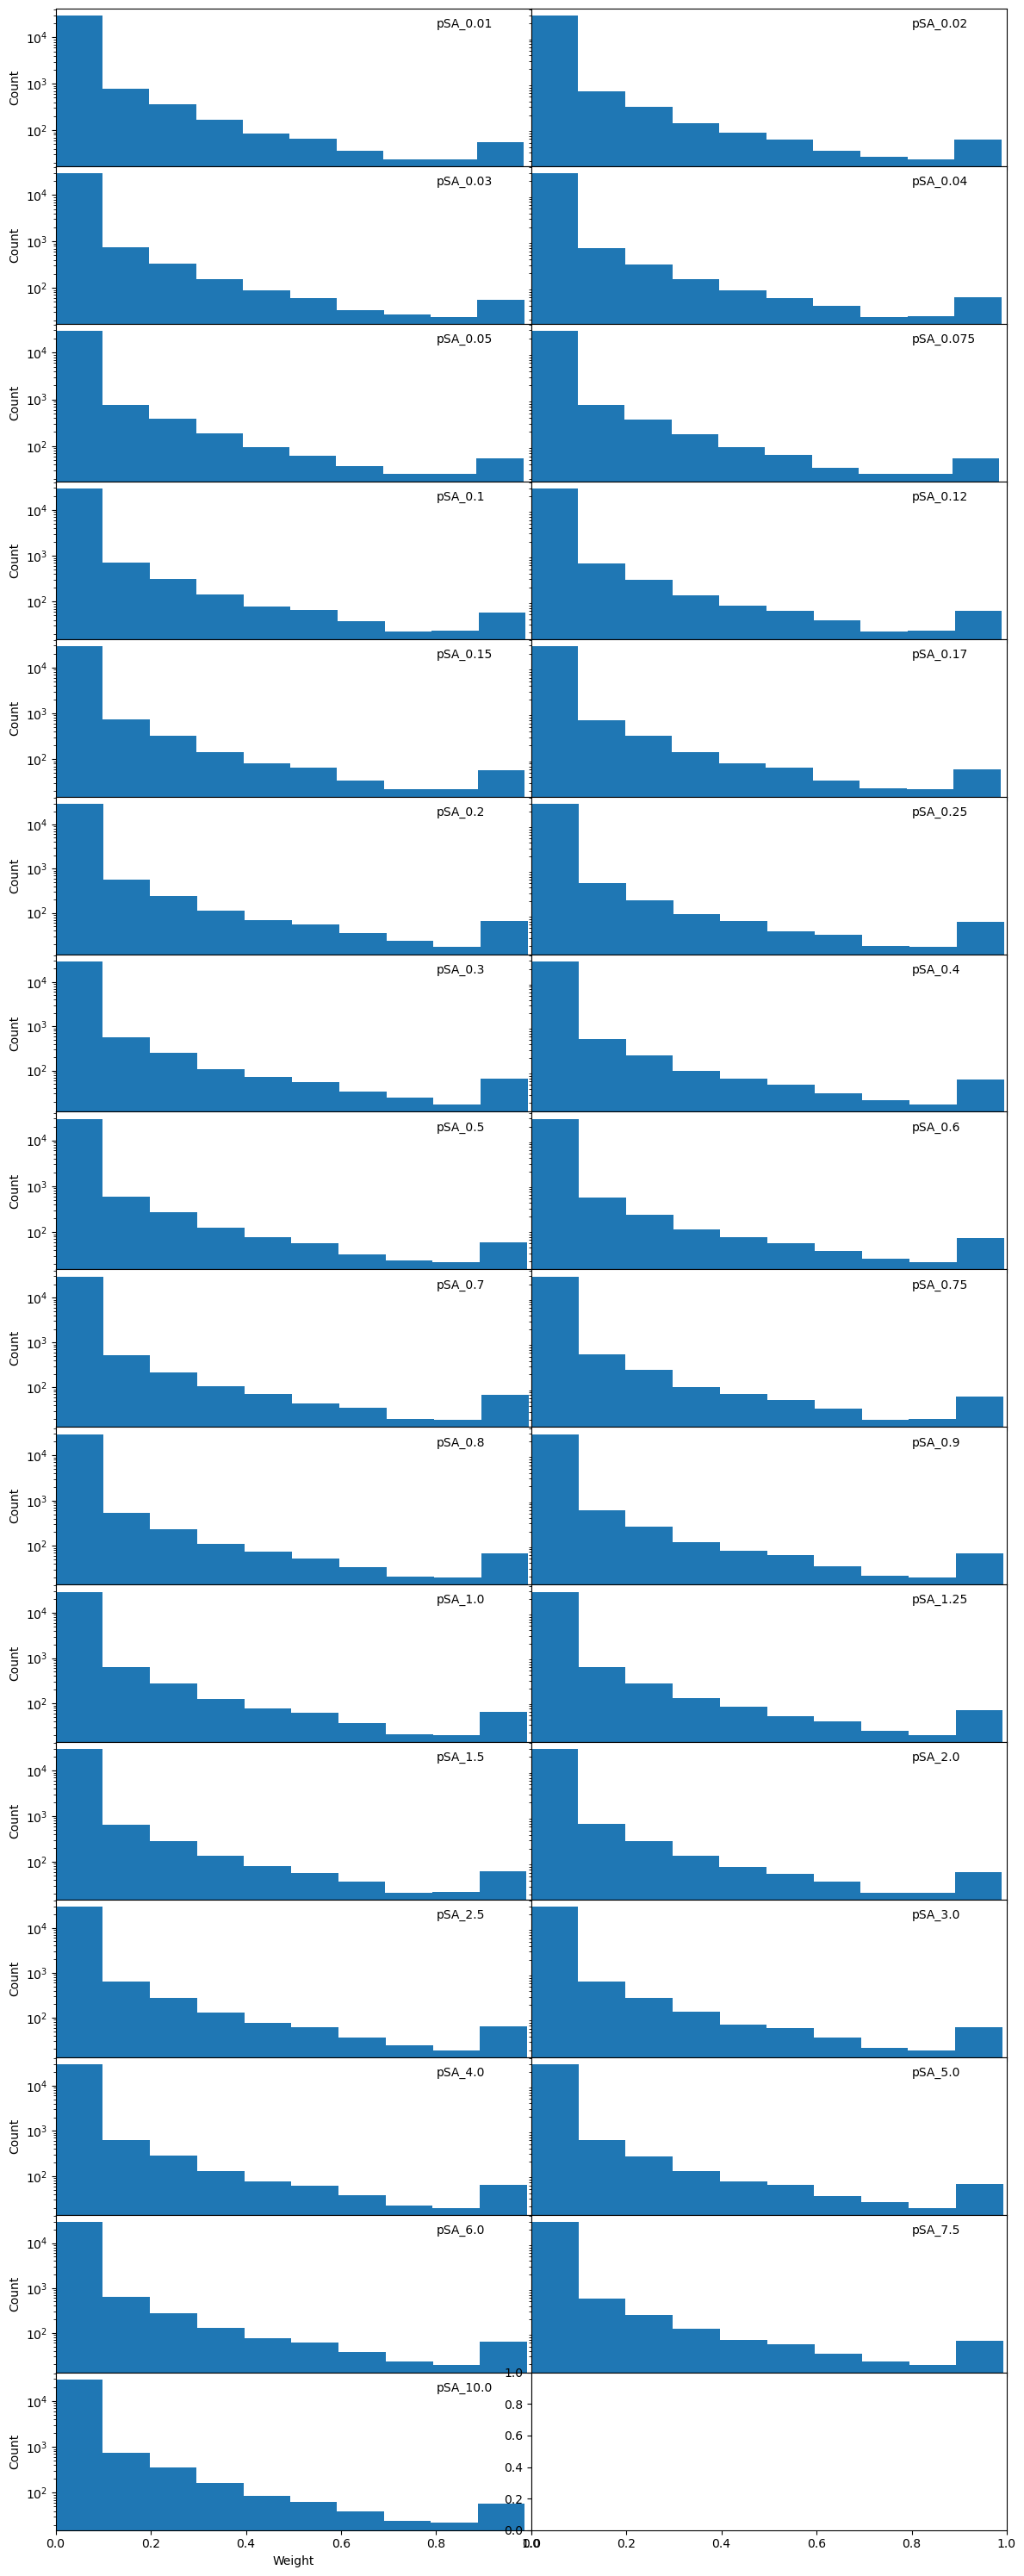

In [31]:
ims = sr.constants.PSA_KEYS

# Create subplots with shared x-axis
fig, axs = plt.subplots(int(np.ceil(len(ims) / 2)), 2, figsize=(12, 30), sharex=True)

axs = axs.flatten()

for i, im in enumerate(ims):
    ax = axs[i]
    ax.hist(result_df[f"{im}_weight"], log=True)
    ax.set_xlim(0, 1)
    ax.set_xlabel("Weight")
    ax.set_ylabel("Count" if i % 2 == 0 else "")
    ax.text(0.85, 0.9, f"{im}", horizontalalignment="left", verticalalignment="center", transform=ax.transAxes)
    
    if i % 2 != 0:  # For the second column, remove y-ticks
        ax.set_yticks([])
        ax.set_yticklabels([])
    

fig.tight_layout()
plt.subplots_adjust(hspace=0, wspace=0)


27.500850677490234